Divide image into meaningful regions (sky, road, object, etc.)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from PIL import Image

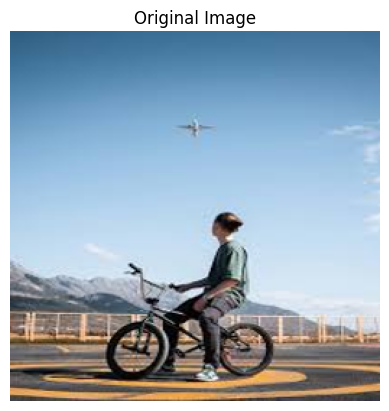

In [12]:
image = Image.open("b.jpg")  
image = image.resize((256, 256))  

plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [13]:
image_np = np.array(image)

h, w, c = image_np.shape

# reshape to (num_pixels, features)
pixels = image_np.reshape(-1, 3)

# normalize (important for clustering)
pixels = pixels.astype(np.float32) / 255.0

In [14]:
# create x, y coordinates
x_coords = np.tile(np.arange(w), (h, 1))
y_coords = np.tile(np.arange(h), (w, 1)).T

# normalize coordinates
x_coords = x_coords / w
y_coords = y_coords / h

# reshape
x_coords = x_coords.reshape(-1, 1)
y_coords = y_coords.reshape(-1, 1)

# combine RGB + position
features = np.concatenate([pixels, x_coords, y_coords], axis=1)

In [15]:
k = 5  # number of segments (try 3–8)

kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000)
labels = kmeans.fit_predict(features)

In [ ]:
segmented = kmeans.cluster_centers_[labels][:, :3] 
segmented = segmented.reshape(h, w, 3)

# convert back to 0-255
segmented = (segmented * 255).astype('uint8')

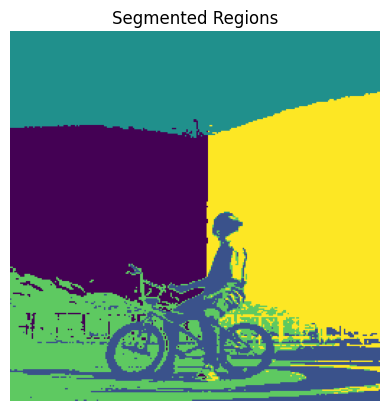

In [17]:
segmented_labels = labels.reshape(h, w)

plt.imshow(segmented_labels, cmap='viridis')
plt.title("Segmented Regions")
plt.axis('off')
plt.show()

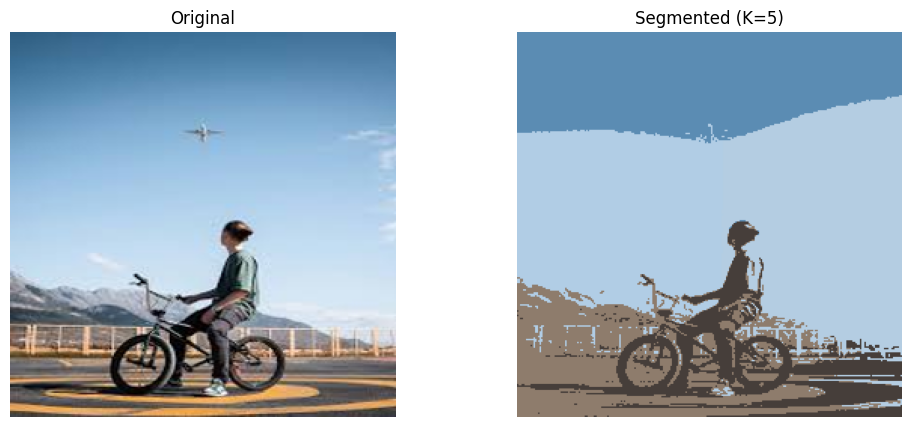

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented)
plt.title(f"Segmented (K={k})")
plt.axis('off')

plt.show()

In [19]:
import cv2
segmented_labels = labels.reshape(h, w)

In [20]:
# detect boundaries (where neighboring pixels have different labels)
boundaries = np.zeros((h, w), dtype=np.uint8)

# check right and bottom neighbors
boundaries[:-1, :] |= (segmented_labels[:-1, :] != segmented_labels[1:, :])
boundaries[:, :-1] |= (segmented_labels[:, :-1] != segmented_labels[:, 1:])

# convert original image to array
original_np = np.array(image)

# overlay boundaries (red color)
boundary_image = original_np.copy()
boundary_image[boundaries == 1] = [255, 0, 0]  # red boundaries

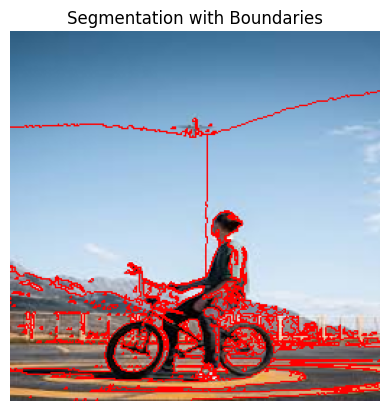

In [21]:
plt.imshow(boundary_image)
plt.title("Segmentation with Boundaries")
plt.axis('off')
plt.show()

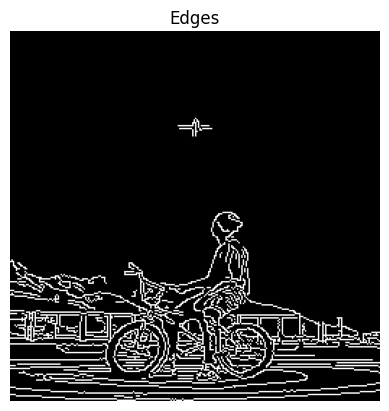

In [22]:
# edge
# convert to grayscale
gray = cv2.cvtColor(original_np, cv2.COLOR_RGB2GRAY)

# apply canny edge detector
edges = cv2.Canny(gray, threshold1=100, threshold2=200)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis('off')
plt.show()

In [23]:
# copy segmented image
seg_with_edges = segmented.copy()

# mark edges in green
seg_with_edges[edges != 0] = [0, 255, 0]  # green edges

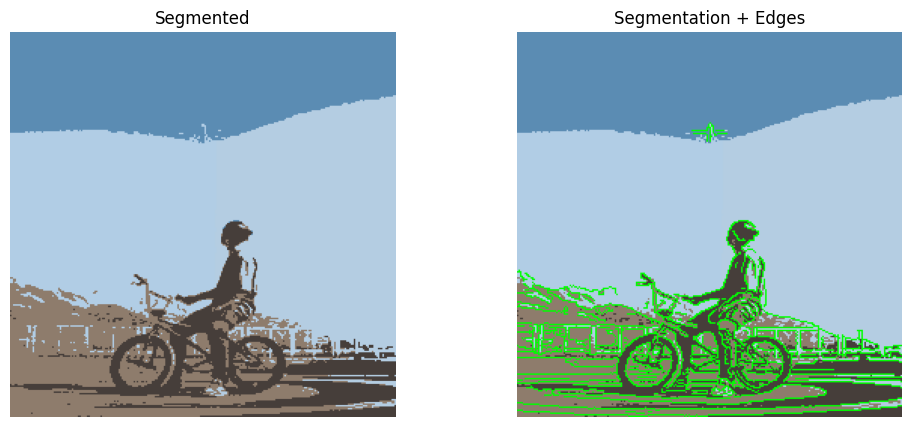

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(segmented)
plt.title("Segmented")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(seg_with_edges)
plt.title("Segmentation + Edges")
plt.axis('off')

plt.show()